In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [38]:
df = pd.read_csv('PGA_Data.csv')
df = df[["player", "season", "sg_ott", "sg_app", "sg_arg", "sg_putt", "sg_total"]]
display(df.head(5))

,player,season,sg_ott,sg_app,sg_arg,sg_putt,sg_total
0,Abraham Ancer,2022,0.86,-0.08,-0.13,0.20,0.85
1,Adam Hadwin,2022,0.18,0.31,0.75,0.36,1.60
2,Anirban Lahiri,2022,0.37,-1.09,0.74,-0.56,-0.54
3,Adam Long,2022,0.80,-0.02,-1.86,-1.46,-2.54
4,Alexander Noren,2022,0.19,-1.39,-0.36,0.53,-1.04


In [39]:
def normalize(series):
    # scale to 0-1 probability
    return (series - series.min()) / (series.max() - series.min())

df["p_tee_fairway"] = normalize(df["sg_ott"])
df["p_fairway_green"] = normalize(df["sg_app"])
df["p_rough_green"] = normalize(df["sg_app"] * 0.6)   
df["p_bunker_green"] = normalize(df["sg_arg"])
df["p_green_hole"] = normalize(df["sg_putt"])


In [40]:
p_tee_fairway   = df["p_tee_fairway"].mean()
p_fairway_green = df["p_fairway_green"].mean()
p_rough_green   = df["p_rough_green"].mean()
p_bunker_green  = df["p_bunker_green"].mean()
p_green_hole    = df["p_green_hole"].mean()

In [41]:
states = ["Tee", "Fairway", "Rough", "Bunker", "Green", "Hole"]
transition_matrix = pd.DataFrame(0.0, index=states, columns=states)

# Tee
transition_matrix.loc["Tee", "Fairway"] = p_tee_fairway
transition_matrix.loc["Tee", "Rough"]   = (1 - p_tee_fairway) * 0.7
transition_matrix.loc["Tee", "Bunker"]  = (1 - p_tee_fairway) * 0.3

# Fairway
# Fairway transitions
transition_matrix.loc["Fairway", "Green"]   = p_fairway_green
transition_matrix.loc["Fairway", "Rough"]   = (1 - p_fairway_green) * 0.5
transition_matrix.loc["Fairway", "Bunker"]  = (1 - p_fairway_green) * 0.3
transition_matrix.loc["Fairway", "Fairway"] = (1 - p_fairway_green) * 0.2 


# Rough
transition_matrix.loc["Rough", "Green"]  = p_rough_green
transition_matrix.loc["Rough", "Rough"]  = (1 - p_rough_green) * 0.5
transition_matrix.loc["Rough", "Bunker"] = (1 - p_rough_green) * 0.5

# Bunker
transition_matrix.loc["Bunker", "Green"] = p_bunker_green
transition_matrix.loc["Bunker", "Rough"] = 1 - p_bunker_green


# Green
transition_matrix.loc["Green", "Hole"]  = p_green_hole
transition_matrix.loc["Green", "Green"] = 1 - p_green_hole

# Hole is absorbing
transition_matrix.loc["Hole", "Hole"] = 1.0

print("Transition Matrix:\n")
print(transition_matrix.round(2))
print(type(transition_matrix))

Transition Matrix:

         Tee  Fairway  Rough  Bunker  Green  Hole
Tee      0.0     0.73   0.19    0.08   0.00  0.00
Fairway  0.0     0.07   0.17    0.10   0.66  0.00
Rough    0.0     0.00   0.17    0.17   0.66  0.00
Bunker   0.0     0.00   0.33    0.00   0.67  0.00
Green    0.0     0.00   0.00    0.00   0.44  0.56
Hole     0.0     0.00   0.00    0.00   0.00  1.00
<class 'pandas.core.frame.DataFrame'>


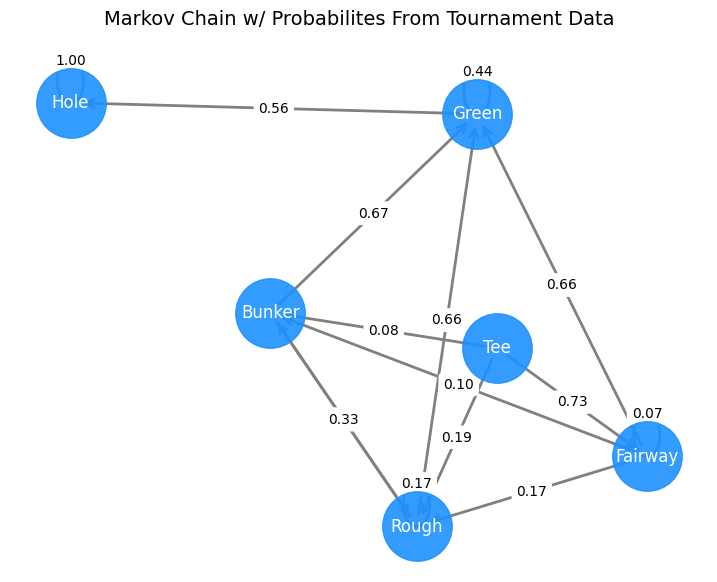

In [42]:
import networkx as nx

# Build graph
G = nx.DiGraph()
for i in states:
    for j in states:
        p = transition_matrix.loc[i, j]
        if p > 0:
            G.add_edge(i, j, weight=p)

pos = nx.spring_layout(G, seed=42, k=1.2)

plt.figure(figsize=(9,7))

# Nodes
nx.draw_networkx_nodes(
    G, pos,
    node_color="dodgerblue",
    node_size=2500,
    alpha=0.9
)

# Normal edges (exclude self-loops)
normal_edges = [(u, v) for u, v in G.edges() if u != v]
nx.draw_networkx_edges(
    G, pos,
    edgelist=normal_edges,
    arrowstyle="->",
    arrowsize=15,
    edge_color="gray",
    width=2,
    connectionstyle="arc3,rad=0.0"  # straight edges
)

# Self-loops only
self_loops = [(u, v) for u, v in G.edges() if u == v]
nx.draw_networkx_edges(
    G, pos,
    edgelist=self_loops,
    arrowstyle="->",
    arrowsize=15,
    edge_color="gray",
    width=2,
    connectionstyle="arc3,rad=0.35"  # bigger curve so it sits outside
)

# Labels
nx.draw_networkx_labels(
    G, pos,
    font_size=12,
    font_color="white"
)

# Edge labels
labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels={k: f"{v:.2f}" for k, v in labels.items()},
    font_size=10,
    font_color="black",
    rotate=False
)

plt.title("Markov Chain w/ Probabilites From Tournament Data", fontsize=14)
plt.axis("off")
plt.show()


In [43]:
def play_one_hole(transition_matrix, start_state="Tee", hole_out="Hole"):
    state = start_state
    strokes = 0
    while state != hole_out:
        # grab probabilities for the current state (row)
        probs = transition_matrix.loc[state].values
        states = transition_matrix.columns
        # sample next state
        next_state = np.random.choice(states, p=probs)
        state = next_state
        strokes += 1
    return strokes

In [44]:
def play_round(transition_matrix, n_holes=18):
    total_strokes = 0
    for _ in range(n_holes):
        total_strokes += play_one_hole(transition_matrix, start_state="Tee", hole_out="Hole")
    return total_strokes

In [45]:
def monte_carlo_expected_strokes(transition_matrix, n_rounds=10000, n_holes=18):
    results = [play_round(transition_matrix, n_holes) for _ in range(n_rounds)]
    mean_strokes = np.mean(results)
    std_strokes = np.std(results)
    return mean_strokes, std_strokes

In [46]:
mean, std = monte_carlo_expected_strokes(transition_matrix, n_rounds=10000, n_holes=18)
print(f"Expected strokes after 18 holes: {mean:.2f} ± {std:.2f}")

Expected strokes after 18 holes: 77.31 ± 6.23


In [47]:
def expected_strokes_absorbing(transition_matrix, start_state="Tee", hole_out="Hole"):
    # Identify transient states (exclude the absorbing state "Hole")
    transient_states = [s for s in transition_matrix.index if s != hole_out]

    # Extract Q (submatrix of transient states)
    Q = transition_matrix.loc[transient_states, transient_states].values

    # Fundamental matrix: N = (I - Q)^(-1)
    I = np.eye(Q.shape[0])
    N = np.linalg.inv(I - Q)

    # Expected steps vector: t = N * 1
    ones = np.ones((Q.shape[0], 1))
    t = N.dot(ones)

    # Map back to states
    expected_steps = dict(zip(transient_states, t.flatten()))

    return expected_steps[start_state]

# Example: expected strokes for 18 holes
exp_one_hole = expected_strokes_absorbing(transition_matrix, start_state="Tee", hole_out="Hole")
print(f"Expected strokes for one hole: {exp_one_hole:.2f}")
print(f"Expected strokes for 18 holes: {exp_one_hole*18:.2f}")


Expected strokes for one hole: 4.29
Expected strokes for 18 holes: 77.29
